In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# load csv dataset
data = pd.read_csv('Churn_Modelling (1).csv')

rows, cols = data.shape
print('Shape :', (rows, cols))
print('Columns :', list(data.columns))

# preview the dataset
data.head()

Shape : (10000, 14)
Columns : ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print('Missing values:')
print(data.isnull().sum())
print('\nDuplicates:', data.duplicated().sum())

data.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
data.drop_duplicates(inplace=True)

print('\nShape after cleaning:', data.shape)

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0

Shape after cleaning: (10000, 11)


In [3]:
stayed  = (data['Exited'] == 0).sum()
churned = (data['Exited'] == 1).sum()
ratio   = stayed / churned

print(f'Stayed  (0) : {stayed}   ({stayed/len(data)*100:.1f}%)')
print(f'Churned (1) : {churned}   ({churned/len(data)*100:.1f}%)')
print(f'\nImbalance ratio : {ratio:.2f}')
print(f'For every 1 churner there are {ratio:.1f} non-churners.')
print(f'Pass ratio={ratio:.2f} as scale_pos_weight to XGBoost.')

Stayed  (0) : 7963   (79.6%)
Churned (1) : 2037   (20.4%)

Imbalance ratio : 3.91
For every 1 churner there are 3.9 non-churners.
Pass ratio=3.91 as scale_pos_weight to XGBoost.


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
print('Gender encoded  : Female=0, Male=1')

data = pd.get_dummies(data, columns=['Geography'], drop_first=True)
print('Geography encoded : one-hot')
print('\nFinal columns:', list(data.columns))

Gender encoded  : Female=0, Male=1
Geography encoded : one-hot

Final columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


In [5]:
data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)
data['IsHighRiskProfile']  = ((data['Age'] > 45) & (data['IsActiveMember'] == 0)).astype(int)
data['ProductsPerTenure']  = data['NumOfProducts'] / (data['Tenure'] + 1)
data['AgeBalanceProduct']  = data['Age'] * (data['Balance'] > 0).astype(int)

print('4 new features added')
print('Total features :', data.shape[1] - 1)

4 new features added
Total features : 15


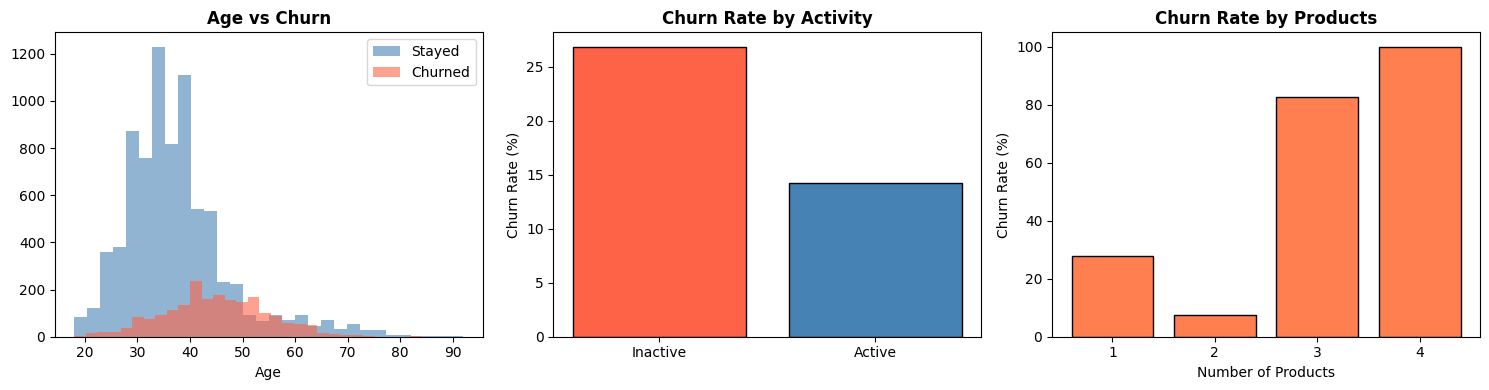

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age vs Churn distibution Plot
axes[0].hist(data[data['Exited']==0]['Age'], bins=30, alpha=0.6, color='steelblue', label='Stayed')
axes[0].hist(data[data['Exited']==1]['Age'], bins=30, alpha=0.6, color='tomato',    label='Churned')
axes[0].set_title('Age vs Churn', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Churn rate by ActiveMember feature based on "IsActiveMember"
active_rate = data.groupby('IsActiveMember')['Exited'].mean() * 100
active_rate.index = ['Inactive', 'Active']
axes[1].bar(active_rate.index, active_rate.values, color=['tomato','steelblue'], edgecolor='black')
axes[1].set_title('Churn Rate by Activity', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')

# Churn rate plot based on NumOfProducts in dataset
prod_rate = data.groupby('NumOfProducts')['Exited'].mean() * 100
axes[2].bar(prod_rate.index.astype(str), prod_rate.values, color='coral', edgecolor='black')
axes[2].set_title('Churn Rate by Products', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_xlabel('Number of Products')

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('Exited', axis=1)
y = data['Exited']

# stratify=y is used to maintain same 80/20 churn ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standarization to normalize feature values
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Calculate imbalance ratio to apply spw technique on imbalanced data
spw_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train samples  : {X_train.shape[0]}')
print(f'Test  samples  : {X_test.shape[0]}')
print(f'Imbalance ratio: {spw_ratio:.2f}')
print(f'scale_pos_weight will be set to: {spw_ratio:.2f}')

Train samples  : 8000
Test  samples  : 2000
Imbalance ratio: 3.91
scale_pos_weight will be set to: 3.91


In [9]:
# weight calculated here
non_churn = len(y_train) - sum(y_train)
churn = sum(y_train)

print("Non-Churn:", non_churn)
print("Churn:", churn)

weight = non_churn / churn
print("Scale Pos Weight:", weight)

Non-Churn: 6370
Churn: 1630
Scale Pos Weight: 3.9079754601226995


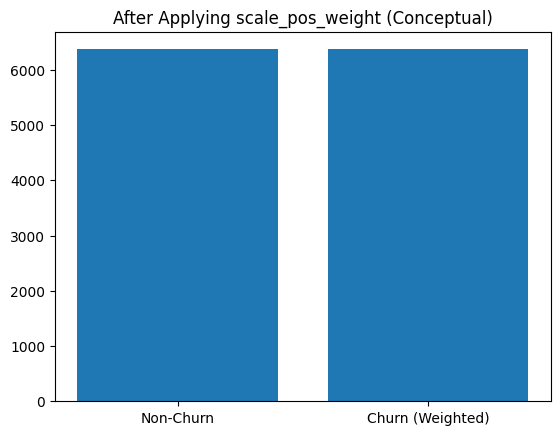

In [10]:
# balanced weight after spw
balanced = [non_churn, non_churn]

plt.bar(['Non-Churn','Churn (Weighted)'], balanced)
plt.title("After Applying scale_pos_weight (Conceptual)")
plt.show()

In [11]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

# Logistic Regression is used a baseline model for comparision
lr_model = LogisticRegression(C=1, max_iter=500, class_weight='balanced', random_state=42)
lr_model.fit(X_train_sc, y_train)

lr_pred  = lr_model.predict(X_test_sc)   # default threshold 0.5
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression Results:')
print(f'  Accuracy  : {accuracy_score(y_test, lr_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_test, lr_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, lr_pred):.4f}')
print(f'  Precision : {precision_score(y_test, lr_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, lr_proba):.4f}')



Logistic Regression Results:
  Accuracy  : 0.7420
  F1 Score  : 0.5000
  Recall    : 0.6339
  Precision : 0.4128
  ROC-AUC   : 0.7791


In [12]:
from xgboost import XGBClassifier

# XGBoost is used as a advanced ensemble model with scale_pos_weight to get optimized model

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_ratio,
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X_train_sc, y_train)

xgb_proba = xgb_model.predict_proba(X_test_sc)[:, 1]
xgb_pred  = xgb_model.predict(X_test_sc)

print('XGBoost (scale_pos_weight) — Default threshold 0.5:')
print(f'  Accuracy  : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'  F1 Score  : {f1_score(y_test, xgb_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, xgb_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, xgb_proba):.4f}')

XGBoost (scale_pos_weight) — Default threshold 0.5:
  Accuracy  : 0.8000
  F1 Score  : 0.6000
  Recall    : 0.7371
  ROC-AUC   : 0.8655


In [13]:
# Recall-aware threshold tuning for XGBoost

best_recall = 0
best_thresh = 0.5

for t in np.arange(0.20, 0.60, 0.01):
    preds = (xgb_proba >= t).astype(int)
    rec   = recall_score(y_test, preds)
    prec  = precision_score(y_test, preds)
    if prec >= 0.45 and rec > best_recall:
        best_recall = rec
        best_thresh = t

xgb_pred_tuned = (xgb_proba >= best_thresh).astype(int)

print(f'Best recall threshold (precision must be >= 0.45): {best_thresh:.2f}')
print(f'  Accuracy  : {accuracy_score(y_test, xgb_pred_tuned):.4f}')
print(f'  Recall    : {recall_score(y_test, xgb_pred_tuned):.4f}')
print(f'  Precision : {precision_score(y_test, xgb_pred_tuned):.4f}')
print(f'  F1 Score  : {f1_score(y_test, xgb_pred_tuned):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, xgb_proba):.4f}')

Best recall threshold (precision must be >= 0.45): 0.42
  Accuracy  : 0.7620
  Recall    : 0.8059
  Precision : 0.4524
  F1 Score  : 0.5795
  ROC-AUC   : 0.8655


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

print('=' * 55)
print('          FINAL MODEL COMPARISON')
print('=' * 55)
print(f'{"Metric":<16} {"Logistic Reg":>16} {"XGBoost":>16}')
print('-' * 55)

metrics = [
    ('Accuracy',  accuracy_score(y_test, lr_pred),    accuracy_score(y_test, xgb_pred_tuned)),
    ('F1 Score',  f1_score(y_test, lr_pred),           f1_score(y_test, xgb_pred_tuned)),
    ('Recall',    recall_score(y_test, lr_pred),        recall_score(y_test, xgb_pred_tuned)),
    ('Precision', precision_score(y_test, lr_pred),     precision_score(y_test, xgb_pred_tuned)),
    ('ROC-AUC',   roc_auc_score(y_test, lr_proba),     roc_auc_score(y_test, xgb_proba)),
]
for name, lv, xv in metrics:
    tag = ' <<' if xv > lv else '   '
    print(f'{name:<16} {lv:>16.4f} {xv:>16.4f}{tag}')

print('=' * 55)
print('<< = XGBoost wins')

          FINAL MODEL COMPARISON
Metric               Logistic Reg          XGBoost
-------------------------------------------------------
Accuracy                   0.7420           0.7620 <<
F1 Score                   0.5000           0.5795 <<
Recall                     0.6339           0.8059 <<
Precision                  0.4128           0.4524 <<
ROC-AUC                    0.7791           0.8655 <<
<< = XGBoost wins


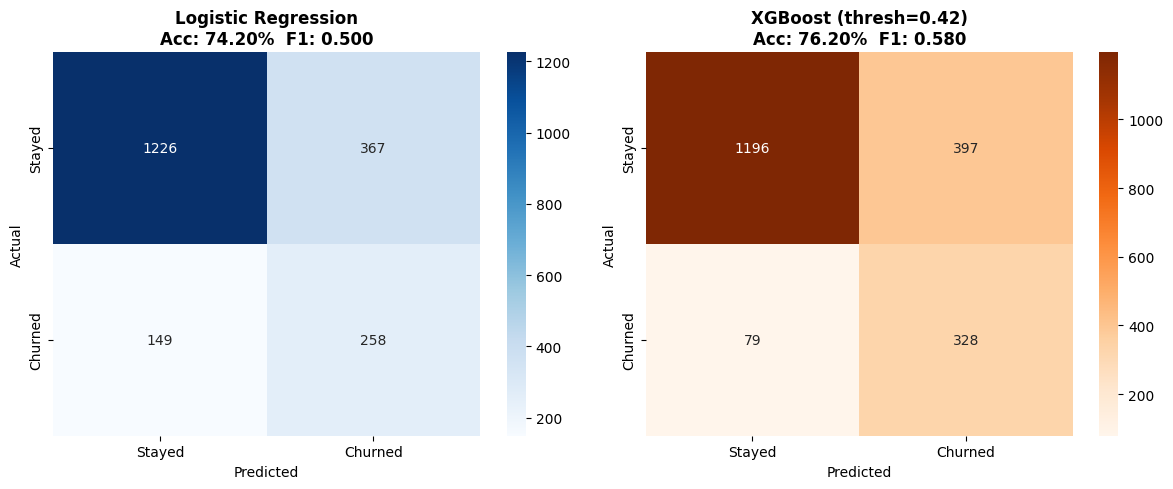

In [15]:
# Confusion matrices for both model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name, cmap in zip(
    axes,
    [lr_pred, xgb_pred_tuned],
    ['Logistic Regression', f'XGBoost (thresh={best_thresh:.2f})'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test,pred):.2%}  F1: {f1_score(y_test,pred):.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matricess.png', dpi=150, bbox_inches='tight')
plt.show()

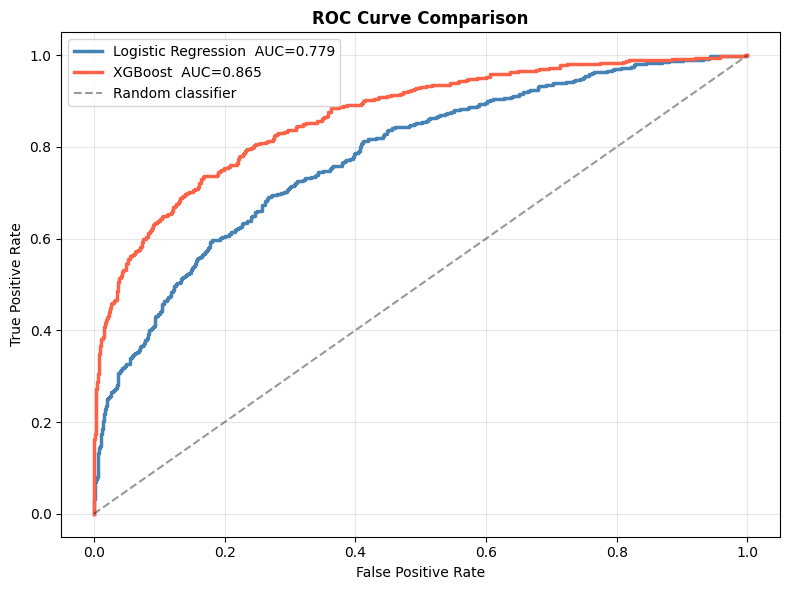

In [16]:
# ROC Curve for comparision
plt.figure(figsize=(8, 6))

for proba, name, color in [
    (lr_proba,  'Logistic Regression', 'steelblue'),
    (xgb_proba, 'XGBoost',             'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  AUC={auc:.3f}', color=color, linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

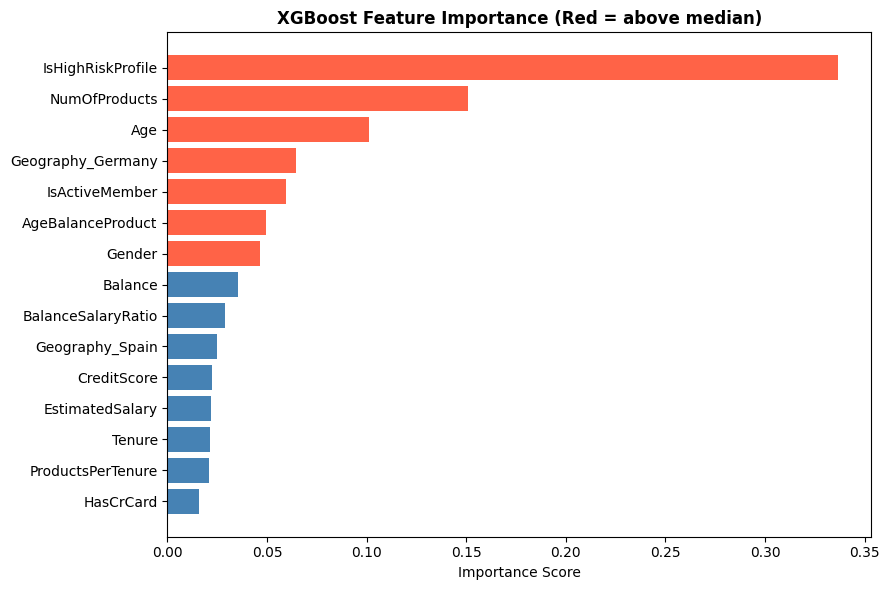

Top 5 features the model found most useful:
IsHighRiskProfile    0.3365
NumOfProducts        0.1510
Age                  0.1011
Geography_Germany    0.0647
IsActiveMember       0.0594
dtype: float32


In [17]:
# Feature Importance is used to understand which feature contributes the most
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

colors = ['tomato' if v > feat_imp.median() else 'steelblue' for v in feat_imp.values]

plt.figure(figsize=(9, 6))
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.title('XGBoost Feature Importance (Red = above median)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features the model found most useful:')
print(feat_imp.sort_values(ascending=False).head(5).round(4))

In [18]:
# Here i started with simple rule based logic approach
def rule_based_risk(row):
    score = 0
    flags = []

    if row['Age'] > 50:
        score += 3
        flags.append('Age > 50')

    if row['IsActiveMember'] == 0:
        score += 3
        flags.append('Inactive member')

    if row['NumOfProducts'] >= 3:
        score += 3
        flags.append('3 or more products')

    if row['CreditScore'] < 500:
        score += 2
        flags.append('Low credit score')

    if row['Tenure'] <= 2:
        score += 1
        flags.append('Short tenure')

    if row['Balance'] == 0:
        score += 1
        flags.append('Zero balance')

    if score >= 6:
        level = 'High Risk'
    elif score >= 3:
        level = 'Medium Risk'
    else:
        level = 'Low Risk'

    return pd.Series({
        'Risk_Level' : level,
        'Risk_Score' : score,
        'Flags'      : ' | '.join(flags) if flags else 'None'
    })


rule_results = data.apply(rule_based_risk, axis=1)
data_rules     = pd.concat([data, rule_results], axis=1)

print('Risk level distribution:')
print(data_rules['Risk_Level'].value_counts())

Risk level distribution:
Risk_Level
Medium Risk    5156
Low Risk       4076
High Risk       768
Name: count, dtype: int64


In [16]:
print('Validating rules — actual churn rate per risk level:')
print('-' * 50)
for level in ['High Risk', 'Medium Risk', 'Low Risk']:
    group = data_rules[data_rules['Risk_Level'] == level]
    rate  = group['Exited'].mean()
    print(f'  {level:12s}: {len(group):5d} customers   actual churn = {rate:.1%}')
print(f'\n  Overall churn rate: {data_rules["Exited"].mean():.1%}')
print('\nIf High Risk >> overall >> Low Risk, rules are correct.')

Validating rules — actual churn rate per risk level:
--------------------------------------------------
  High Risk   :   768 customers   actual churn = 71.1%
  Medium Risk :  5156 customers   actual churn = 20.5%
  Low Risk    :  4076 customers   actual churn = 10.6%

  Overall churn rate: 20.4%

If High Risk >> overall >> Low Risk, rules are correct.


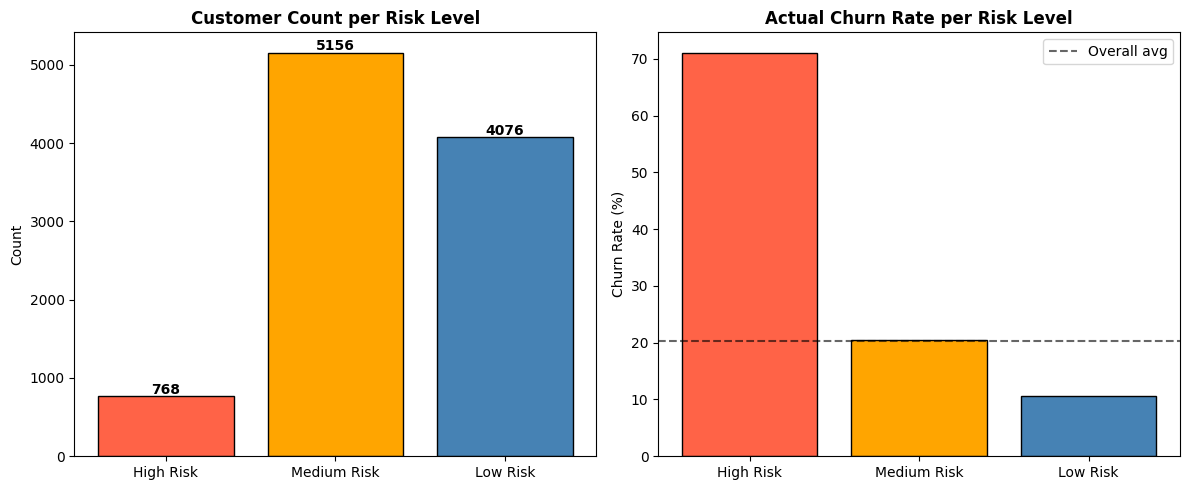

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
colors     = ['tomato', 'orange', 'steelblue']

counts = data_rules['Risk_Level'].value_counts().reindex(risk_order)
axes[0].bar(risk_order, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Customer Count per Risk Level', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

rates = [data_rules[data_rules['Risk_Level']==l]['Exited'].mean()*100 for l in risk_order]
axes[1].bar(risk_order, rates, color=colors, edgecolor='black')
axes[1].axhline(y=data_rules['Exited'].mean()*100, color='black',
                linestyle='--', alpha=0.6, label='Overall avg')
axes[1].set_title('Actual Churn Rate per Risk Level', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('rule_baseds.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print('=' * 58)
print('              FINAL SUMMARY')
print('=' * 58)
print(f'  Imbalance technique : scale_pos_weight = {spw_ratio:.2f}')
print(f'  Best threshold      : {best_thresh:.2f}')
print(f'  Total features      : {X.shape[1]} (including 4 engineered)')
print(f'  Training samples    : {X_train.shape[0]}')
print(f'  Test samples        : {X_test.shape[0]}')
print(f'  Unseen samples      : 5 new customers')
print('-' * 58)
print(f'  XGBoost Accuracy    : {accuracy_score(y_test, xgb_pred_tuned):.4f}')
print(f'  XGBoost F1 Score    : {f1_score(y_test, xgb_pred_tuned):.4f}')
print(f'  XGBoost Recall      : {recall_score(y_test, xgb_pred_tuned):.4f}')
print(f'  XGBoost ROC-AUC     : {roc_auc_score(y_test, xgb_proba):.4f}')
print('=' * 58)
print('  Data changed?       : NO — scale_pos_weight only')
print('  Winner              : XGBoost')

              FINAL SUMMARY
  Imbalance technique : scale_pos_weight = 3.91
  Best threshold      : 0.42
  Total features      : 15 (including 4 engineered)
  Training samples    : 8000
  Test samples        : 2000
  Unseen samples      : 5 new customers
----------------------------------------------------------
  XGBoost Accuracy    : 0.7620
  XGBoost F1 Score    : 0.5795
  XGBoost Recall      : 0.8059
  XGBoost ROC-AUC     : 0.8655
  Data changed?       : NO — scale_pos_weight only
  Winner              : XGBoost
